In [2]:
import numpy as np
import matplotlib.pyplot as plt

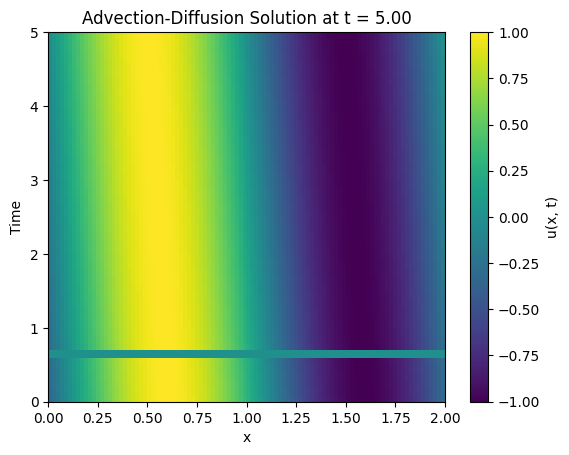

In [41]:
def advection_diffusion(u, C, D):
    """
    Compute the new time derivative of the solution given the equation coefficients C, D and the current solution u.
    """
    # Compute the spatial derivatives
    du_dx = np.gradient(u, axis=0)
    du_dxx = np.gradient(du_dx, axis=0)
    
    # Compute the time derivative using the advection-diffusion equation
    du_dt = -C * du_dx + D * du_dxx
    
    return du_dt

# Generate u(x, 0)
x = np.linspace(0, 2, 100)
u0 = np.sin(np.pi * x)
# Define coefficients
C = 1  # Advection coefficient
D = 0  # Diffusion coefficient
# define time propagation parameters
t_final = 5.0
dt = 0.1

u_matrix = np.zeros((int(t_final/dt), len(x)))
# Time integration using Euler's method
u = u0.copy()
for t in np.arange(0, t_final, dt):
    du_dt = advection_diffusion(u, C, D)
    u += du_dt * dt
    u_matrix[int(t/dt), :] = u

# Plot the results on a heatmap to resemble 3d graph
plt.imshow(u_matrix, extent=[x.min(), x.max(), 0, t_final], aspect='auto', cmap='viridis')
plt.colorbar(label='u(x, t)')
plt.xlabel('x')
plt.ylabel('Time')
plt.title('Advection-Diffusion Solution at t = {:.2f}'.format(t_final))
plt.show()